![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Final Project - Design

#### By: Sergi Nàcher Muñoz

## 0. Imports 

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
from matplotlib.pyplot import cm

import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

/var/folders/l8/3nhlx6bj305_vfsnlb1w6_480000gn/T/ipykernel_30159/576301165.py:13: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


In [2]:
nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength

### 0.2. Materials

In [3]:
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Part I. Design and Simulation of Individual Components 

## 1. Simulating Propagation Modes in SOI Waveguides

### 1.1. Define the SOI waveguide structure (450 nm width, 220 nm thickness). 

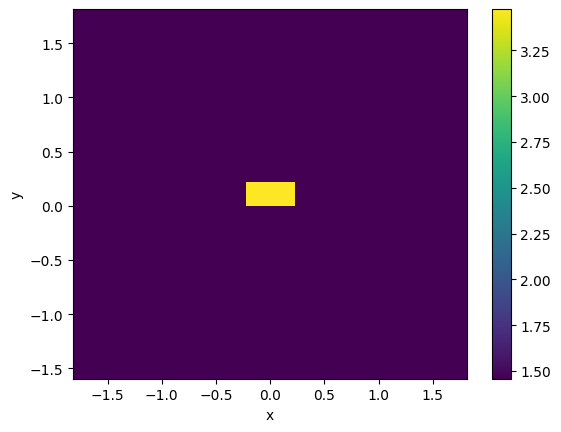

In [4]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width = 0.45, # Waveguide width
    core_thickness = 0.22, # Waveguide height 
    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = 1550 * nm, # Wavelength to simulate
    num_modes = 4, # Targeted number of modes to find 
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20, # Parameters of the grid
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double'
)

deep_waveguide.plot_index()

### 1.2. Simulate fundamental TE and TM modes. 

In [5]:
deep_waveguide.n_eff

2026-05-15 00:39:16.514 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_198a1ab0a96c4a6f.npz.


array([2.33508782+7.05715980e-05j, 1.7447082 +2.39341986e-04j,
       1.46251286+2.05632472e-04j, 1.43196857+2.18207211e-04j])

In [6]:
deep_waveguide.fraction_te

array([0.960726  , 0.06940437, 0.64309704, 0.99810644])

In [7]:
deep_waveguide.fraction_tm

array([0.039274  , 0.93059563, 0.35690296, 0.00189356])

Text(0.5, 1.0, 'Modo 0 - Campo Ex (Modo TE0)')

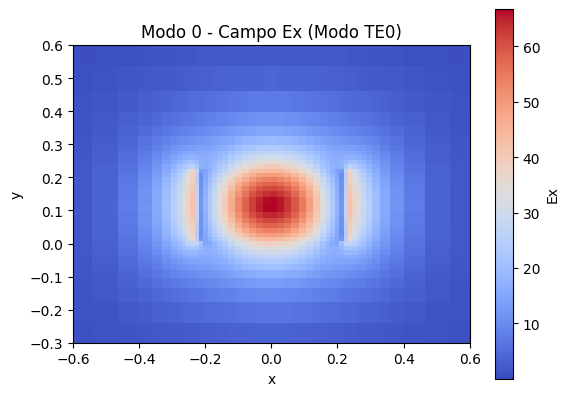

In [8]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 0 - Campo Ex (Modo TE0)')

Text(0.5, 1.0, 'Modo 1 - Campo Ey (Modo TM0)')

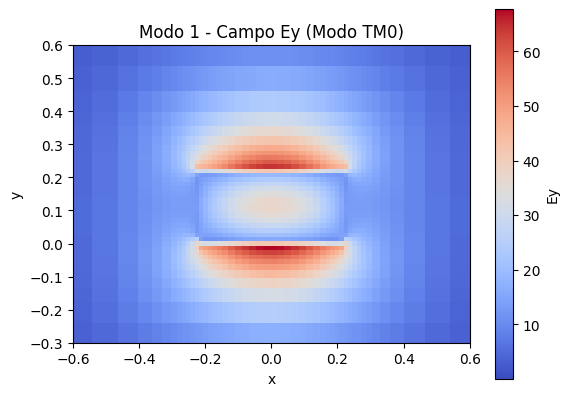

In [9]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 1 - Campo Ey (Modo TM0)')

Para el modo fundamental TM0 se puede observar un campo poco confinado en el núcleo, y en su lugar la luz viaja por el cladding.

Ya tenemos los modos fundamentales tanto para TE como para TM. Ahora vamos a verificar que los demás modos están en corte

Text(0.5, 1.0, 'Modo 2 - Campo Ex')

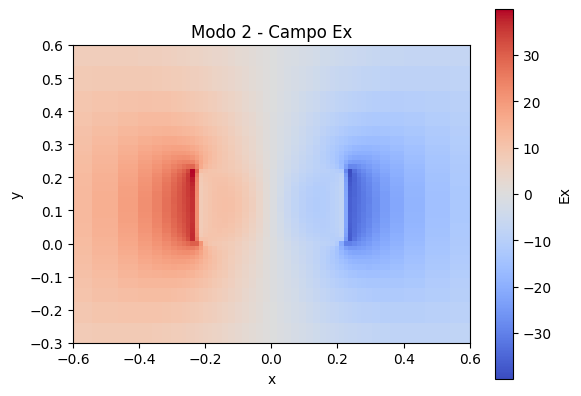

In [10]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ex')

Text(0.5, 1.0, 'Modo 2 - Campo Ey')

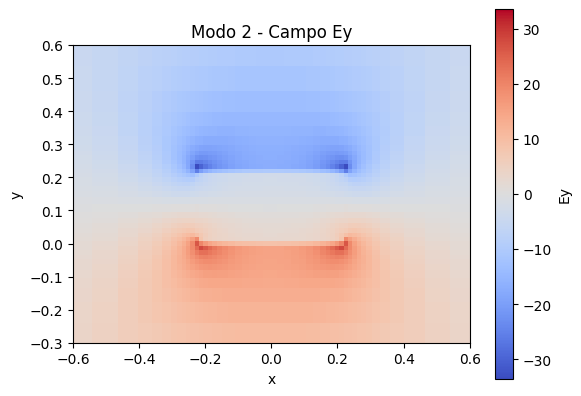

In [11]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ey')

Por tanto, hemos verificado que los siguientes modos estarán en corte como ya se había previsto.

### 1.3. Extract effective index (n_eff) and group index (n_g) values. 

In [12]:
# Índice efectivo TE0 y TM0

n_eff_TE = deep_waveguide.n_eff.real[0]
n_eff_TM = deep_waveguide.n_eff.real[1]
print(f"Índice efectivo del modo TE0: {n_eff_TE:.4f}")
print(f"Índice efectivo del modo TM0: {n_eff_TM:.4f}")

Índice efectivo del modo TE0: 2.3351
Índice efectivo del modo TM0: 1.7447


In [13]:
'''
wavelengths = np.linspace(1.5,1.6,11)
lambda_0 = 1.55

deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width = 0.45, # Waveguide width
    core_thickness = 0.22, # Waveguide height 
    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = wavelengths, # Wavelength to simulate
    num_modes = 4, # Targeted number of modes to find 
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20, # Parameters of the grid
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double'
)


lista = [n_eff_TE, n_eff_TM]

# Centramos la longitud de onda

X = wavelengths - lambda_0

# Ajuste polinómico de grado 2

s = 0

for i in lista:

    coeffs = np.polyfit(X, i, 2)   # polyfit devuelve [coef_cuadratico, coef_lineal, termino_indep]

    n3 = coeffs[0]  # Término cuadrático
    n2 = coeffs[1]  # Término lineal
    n1 = coeffs[2]  # Término independiente

    # Cálculo de n_g y D
    n_g = n1 - n2 * lambda_0
    c = 3e8
    D = -(2 * lambda_0 * n3) / c
    n_eff =  n1 + n2 * (X) + n3 * (X)**2
    

    if s == 0:
        print('Para la guía de onda deep y modo TE: \n'
        f'n1 = {n1:.4f}, n2 = {n2:.4f}, n3 = {n3:.4f}, n_g = {n_g:.4f}, D = {D} \n')
        plt.plot(wavelengths,n_eff, '-o', label ='n_eff_TE_deep')

    elif s == 1: 
        print('Para la guía de onda deep y modo TM: \n'
        f'n1 = {n1:.4f}, n2 = {n2:.4f}, n3 = {n3:.4f}, n_g = {n_g:.4f}, D = {D} \n')
        plt.plot(wavelengths,n_eff, '-o', label ='n_eff_TM_deep')

        # Configuración final del gráfico
        plt.xlabel("Wavelength ($\mu m$)")
        plt.ylabel("Effective index ($n_{eff}$)")
        plt.title("Ajuste polinómico de modos (Guía deep)")
        plt.grid()
        plt.legend() 
        plt.show()

    s += 1

'''

<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
/var/folders/l8/3nhlx6bj305_vfsnlb1w6_480000gn/T/ipykernel_30159/2040231127.py:59: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Wavelength ($\mu m$)")


'\nwavelengths = np.linspace(1.5,1.6,11)\nlambda_0 = 1.55\n\ndeep_waveguide = gt.modes.Waveguide(\n    # Geometrical Parameters\n    core_width = 0.45, # Waveguide width\n    core_thickness = 0.22, # Waveguide height \n    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.\n    # Materials\n    core_material = \'si\', #  Material of the waveguide\n    clad_material = \'sio2\', # Surrounding material\n    # Modesolver Parameters\n    wavelength = wavelengths, # Wavelength to simulate\n    num_modes = 4, # Targeted number of modes to find \n    max_grid_scaling = 1.5, # Parameters of the grid\n    grid_resolution = 20, # Parameters of the grid\n    cache_path = \'.cache/\', # Important! In order to save simulation time, set your cache Path!\n    precision = \'double\'\n)\n\n\nlista = [n_eff_TE, n_eff_TM]\n\n# Centramos la longitud de onda\n\nX = wavelengths - lambda_0\n\n# Ajuste polinómico de grado 2\n\ns = 0\n\nfor i in lista:\n\n    coeffs = np.po

## 2. Designing Directional Couplers

### 2.1. Simulate directional couplers in GDSFactory. 

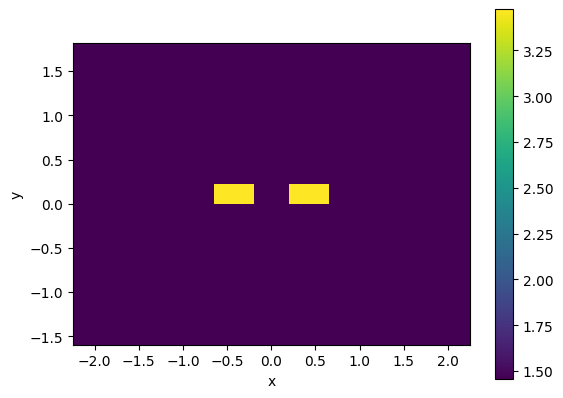

In [14]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width = (0.45, 0.45), # Waveguide width
    slab_thickness = 0, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness = 0.22, # Waveguide height 
    gap = 0.4,
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = lambda_c, # Wavelength to simulate
    num_modes = 6, # Number of modes to find
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double',
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 2.2. Sweep different gap values and coupling lengths. 

In [15]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-15 00:39:16.916 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_ffe9090b758fa39f.npz.
[2.35816142+6.53289443e-05j 2.33459217+7.01480984e-05j
 1.77349409+2.32176528e-04j 1.72117362+2.47894303e-04j
 1.47655318+2.00030999e-04j 1.4489136 +2.10230439e-04j]


In [16]:
dcoupler_cs.fraction_te

array([0.96692074, 0.96082553, 0.06235488, 0.07784008, 0.74575472,
       0.38924343])

In [17]:
dcoupler_cs.fraction_tm

array([0.03307926, 0.03917447, 0.93764512, 0.92215992, 0.25424528,
       0.61075657])

#### Plots

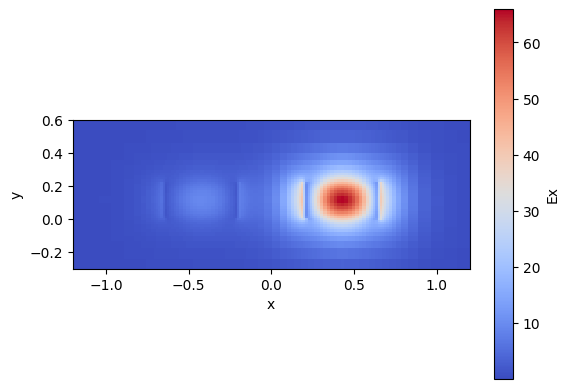

In [18]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.2, 1.2), # Set the x and y limits
                          ylim=(-0.3, 0.6)
)

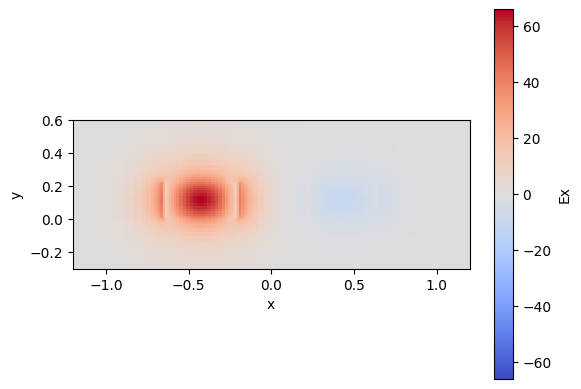

In [19]:
dcoupler_cs.plot_field(mode_index=1, # Mode to be plotted
                          field_name='Ex',  # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.2, 1.2), # Set the x and y limits
                          ylim=(-0.3, 0.6)
)

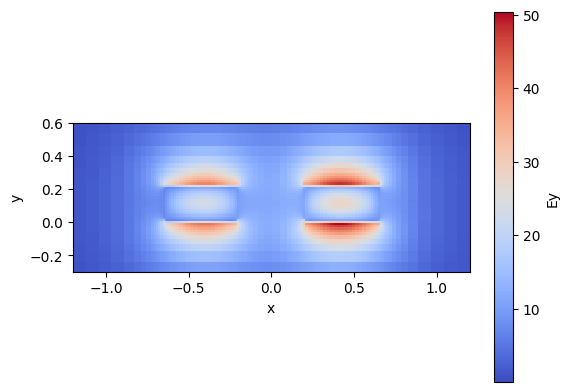

In [20]:
dcoupler_cs.plot_field(mode_index=2, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.2, 1.2), # Set the x and y limits
                          ylim=(-0.3, 0.6)
)

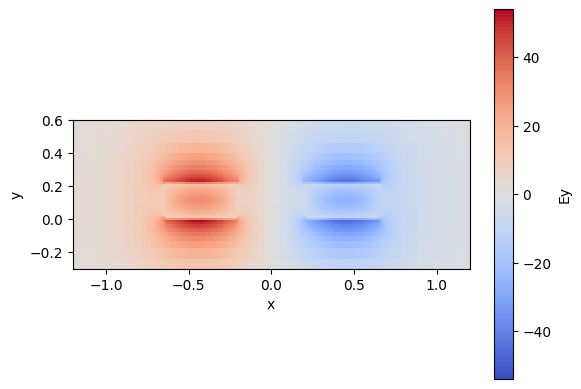

In [21]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.2, 1.2), # Set the x and y limits
                          ylim=(-0.3, 0.6)
)

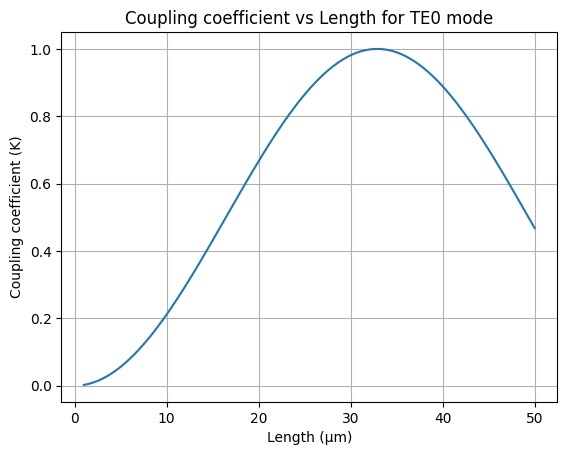

In [22]:
length_values = np.linspace(1,50,200)
dcoupler_cs.gap = 0.4

L_pi_TE0 = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
L_pi_TM0 = 0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)

K_values = []

for length in length_values:
    K = np.sin(1/2 * np.pi * (length/L_pi_TE0))**2
    K_values.append(K)

plt.plot(length_values, K_values)
plt.xlabel("Length (µm)")
plt.ylabel("Coupling coefficient (K)")
plt.title("Coupling coefficient vs Length for TE0 mode")
plt.grid()
plt.show()

### 2.3. Extract coupling coefficients (e.g., 0.5, 0.3, 0.23, etc.).

In [23]:
K_targets = [0.05, 0.17, 0.23, 0.3, 0.5]

print("Lengths for different K values:")
for K_target in K_targets:
    length_target = (L_pi_TE0 * 2 / np.pi) * np.arcsin(np.sqrt(K_target))
    print(f"Length for K={K_target}: {length_target:.2f} µm")

Lengths for different K values:
Length for K=0.05: 4.72 µm
Length for K=0.17: 8.90 µm
Length for K=0.23: 10.47 µm
Length for K=0.3: 12.13 µm
Length for K=0.5: 16.44 µm


## 3. Cascaded MZI Filter and SAX Model

### 3.1. Extract the S-matrix from individual components

In [24]:
# Waveguide Model

def waveguide(wl=1.55, neff=3.48, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


# Coupler Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

### 3.2. Define two arms of the MZI with different lengths

In [25]:
# MZI

mzi, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",  # Definimos el acoplador de entrada coup_a
            "wvg_u": "waveguide",  # Definimos la guía superior wvg_u
            "wvg_d": "waveguide",  # Definimos la guía inferior wvg_d
            "coup_b": "coupler",  # Definimos el acoplador de salida coup_b
        },
        "connections": {
            "coup_a,out0": "wvg_d,in0",  # El out0 de coup_a se conecta al in0 de wvg_d
            "wvg_d,out0": "coup_b,in0",  # El out0 de wvg_d se conecta al in0 de coup_b
            "coup_a,out1": "wvg_u,in0",  # El out1 de coup_a se conecta al in0 de wvg_u
            "wvg_u,out0": "coup_b,in1",  # El out0 de wvg_u se conecta al in1 de coup_b
        },
        "ports": {
            "in0": "coup_a,in0",  # El puerto de entrada del circuito se conecta al in0 de coup_a
            "in1": "coup_a,in1",  # El puerto de entrada del circuito se conecta al in1 de coup_a
            "out0": "coup_b,out0",  # El puerto de salida del circuito se conecta al out0 de coup_b
            "out1": "coup_b,out1",  # El puerto de salida del circuito se conecta al out1 de coup_b
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

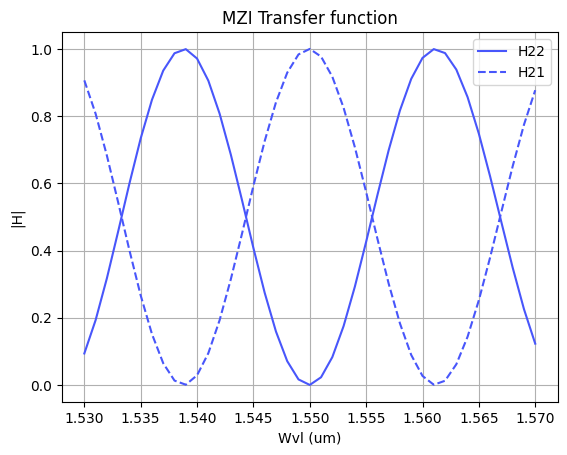

In [26]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 50; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

In [27]:
# =====================================================================
# 3.2 Define two arms of the MZI with different lengths
# =====================================================================

# 1. Definir los parámetros dados por el paper
lambda_0 = 1550 * nm       # Longitud de onda central a alinear (1.55 um)
FSR_S1 = 40 * nm           # FSR para la primera etapa MZI (S1)
FSR_S2 = 80 * nm           # FSR para la segunda etapa MZI (S2)

# 2. Extraer n_eff y n_g del modo TE0 fundamental simulado en el Paso 1
# (Asegúrate de haber calculado n_g previamente; el paper indica que ronda ~4.4 para 450nm)
# Tomamos la parte real del índice efectivo del modo TE0
n_eff_TE = deep_waveguide.n_eff[0].real 

# Si no calculaste n_g_TE en la parte de simulación modal usando la derivada, 
# el paper establece que es aproximadamente 4.4 para una guía de 450nm a 1550nm.
n_g_TE = 4.4 

# Fijamos la longitud del brazo 1 (L1) arbitrariamente (ej. 100 um)
# Esto puede reajustarse más adelante por requisitos de espaciado en el layout (Paso 4)
L1 = 100.0 

def calcular_L2_y_fase(L1, lambda_0, FSR, n_eff, n_g):
    """
    Calcula la longitud del segundo brazo (L2) para cumplir el FSR y 
    la ecuación de condición de fase (Eq 1) del paper.
    """
    # Paso A: Estimar el Delta L a partir del FSR deseado
    delta_L_approx = (lambda_0**2) / (n_g * FSR)
    
    # Paso B: Encontrar el entero de interferencia 'm' (Condición de la Ec. 1)
    # m = n_eff * L / lambda_0
    m = np.round((n_eff * delta_L_approx) / lambda_0)
    
    # Paso C: Recalcular el Delta L exacto que alinea la malla al canal
    delta_L_exact = (m * lambda_0) / n_eff
    
    # Paso D: Hallar la longitud final del brazo 2
    L2 = L1 + delta_L_exact
    
    return L2, delta_L_exact, m

# --- Ejecutamos para la Etapa S1 ---
L2_S1, dL_S1, m_S1 = calcular_L2_y_fase(L1, lambda_0, FSR_S1, n_eff_TE, n_g_TE)

# --- Ejecutamos para la Etapa S2 ---
L2_S2, dL_S2, m_S2 = calcular_L2_y_fase(L1, lambda_0, FSR_S2, n_eff_TE, n_g_TE)

# Mostramos los resultados por pantalla
print("=== ETAPA S1 (FSR = 40 nm) ===")
print(f"Longitud L1 fija : {L1:.3f} µm")
print(f"Longitud L2 calc : {L2_S1:.3f} µm")
print(f"Diferencia \u0394L    : {dL_S1:.3f} µm")
print(f"Orden de interf m: {m_S1}\n")

print("=== ETAPA S2 (FSR = 80 nm) ===")
print(f"Longitud L1 fija : {L1:.3f} µm")
print(f"Longitud L2 calc : {L2_S2:.3f} µm")
print(f"Diferencia \u0394L    : {dL_S2:.3f} µm")
print(f"Orden de interf m: {m_S2}")

=== ETAPA S1 (FSR = 40 nm) ===
Longitud L1 fija : 100.000 µm
Longitud L2 calc : 113.940 µm
Diferencia ΔL    : 13.940 µm
Orden de interf m: 21.0

=== ETAPA S2 (FSR = 80 nm) ===
Longitud L1 fija : 100.000 µm
Longitud L2 calc : 106.638 µm
Diferencia ΔL    : 6.638 µm
Orden de interf m: 10.0


In [28]:
# Hacer un barrido de longitudes. que confifuración de L1 y L2 
#Recalcular als longitudes para obtener las FSR que de piden en S1 y en S2. Se fija L1 y se halla L2 (mediante una fórmula)